Manufacturing processes generate large volumes of sensor data. 
This project aims to predict defective products based on process variables, enabling early intervention and reducing scrap rates.

In [2]:
import pandas as pd

# Cargar dataset
df = pd.read_csv("ai4i2020.csv")

# Ver primeras filas
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [3]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## Problem Definition

This project aims to predict machine failures based on process variables such as temperature, rotational speed, torque, and tool wear.

Rather than focusing solely on prediction, the objective is to identify key process conditions that lead to failures, enabling early intervention and improved quality control.

In [5]:
df_model = df.copy()

# Eliminar IDs
df_model = df_model.drop(['UDI', 'Product ID'], axis=1)

df_model.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


Non-informative identifiers were removed to focus the analysis on process variables.

In [7]:
df_model.shape

(10000, 12)

In [8]:
df_model['Machine failure'].value_counts(normalize=True)

0    0.9661
1    0.0339
Name: Machine failure, dtype: float64

## Class Distribution

Analyzing the distribution of machine failures to detect potential class imbalance.

## Class Imbalance

The dataset is highly imbalanced:

- 96.6% of observations correspond to normal operation
- Only 3.4% represent machine failures

This imbalance presents a significant challenge for modeling, as standard accuracy metrics may be misleading. The focus should instead be on correctly identifying failure cases.

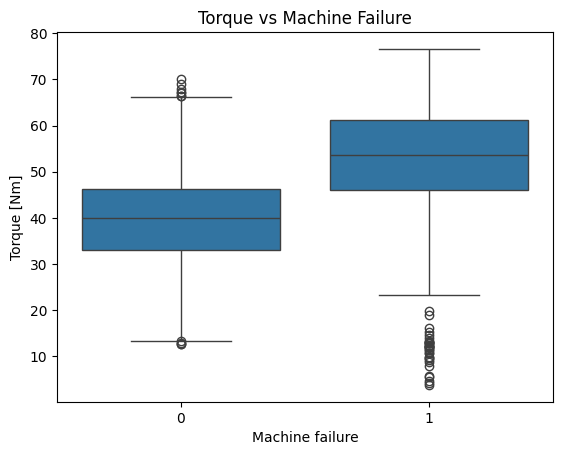

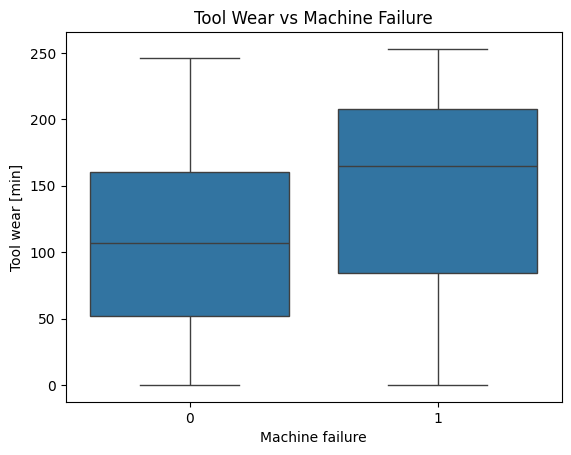

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# Torque vs failure
sns.boxplot(x='Machine failure', y='Torque [Nm]', data=df_model)
plt.title("Torque vs Machine Failure")
plt.show()

# Tool wear vs failure
sns.boxplot(x='Machine failure', y='Tool wear [min]', data=df_model)
plt.title("Tool Wear vs Machine Failure")
plt.show()

## Exploratory Analysis

Analyzing how key process variables differ between normal operation and failure conditions.

### Key Insight

Tool wear shows a strong relationship with machine failure. Failed cases tend to have significantly higher tool wear values.

This suggests that monitoring tool degradation is critical for preventing failures and improving process stability.

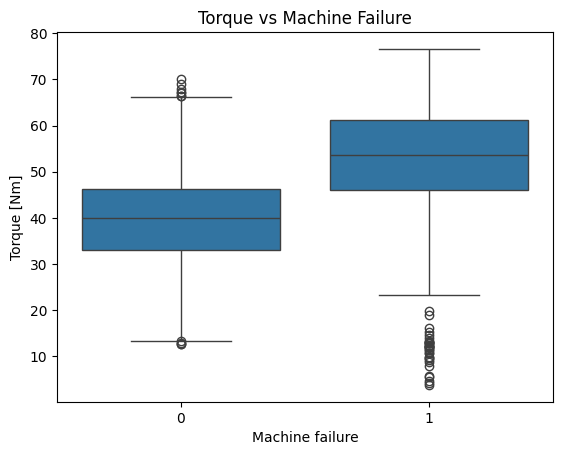

In [14]:
sns.boxplot(x='Machine failure', y='Torque [Nm]', data=df_model)
plt.title("Torque vs Machine Failure")
plt.show()

### Combined Insight

Both tool wear and torque show strong relationships with machine failure.

- Higher tool wear indicates degraded equipment condition
- Higher torque reflects increased mechanical load

Together, these variables suggest that failures are driven by a combination of wear and operational stress, rather than random events.

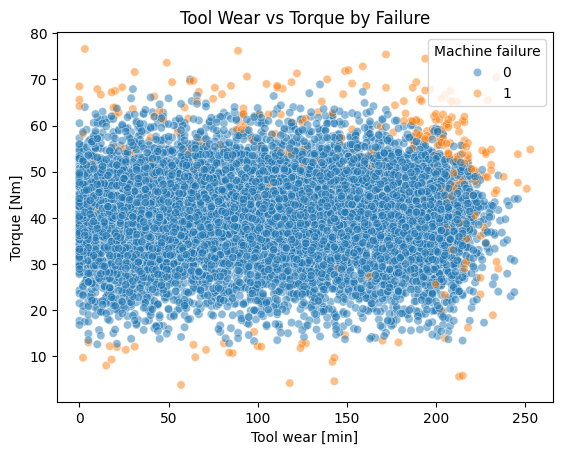

In [16]:
sns.scatterplot(
    x='Tool wear [min]',
    y='Torque [Nm]',
    hue='Machine failure',
    data=df_model,
    alpha=0.5
)

plt.title("Tool Wear vs Torque by Failure")
plt.show()

### Multivariate Behavior

The relationship between tool wear and torque does not show a clear linear boundary separating failure and non-failure cases.

Failures appear across a range of values but are more concentrated in regions with higher tool wear and torque.

This suggests that machine failure is driven by a combination of process conditions rather than a single threshold, reinforcing the need for multivariate modeling.

In [18]:
# Copia
df_ml = df_model.copy()

# Encoding de Type
df_ml = pd.get_dummies(df_ml, columns=['Type'], drop_first=True)

# Variables
X = df_ml.drop('Machine failure', axis=1)
y = df_ml['Machine failure']

X.shape

(10000, 12)

## Data Preparation for Modeling

Categorical variables were encoded and the dataset was prepared for machine learning to predict machine failures.

In [20]:
from sklearn.model_selection import train_test_split

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train.shape, X_test.shape

((8000, 12), (2000, 12))

## Train-Test Split

The dataset was split while preserving class distribution to ensure proper evaluation of rare failure events.

In [22]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, class_weight='balanced')

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


A Logistic Regression model with class balancing was used to address the severe class imbalance in failure prediction.

In [24]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1932
           1       1.00      0.97      0.99        68

    accuracy                           1.00      2000
   macro avg       1.00      0.99      0.99      2000
weighted avg       1.00      1.00      1.00      2000



### Initial Model Observation

The initial model shows near-perfect performance, with extremely high precision and recall.

Such results are uncommon in real-world industrial problems and may indicate the presence of data leakage.

This suggests that some input variables may be directly related to the target variable, artificially inflating model performance.

### Data Leakage Impact

The initial near-perfect performance was driven by variables that directly encoded failure information.

Once these variables were removed, model performance decreased significantly, revealing a more realistic and challenging prediction problem.

This confirms that the original model was not learning true process behavior, but rather exploiting information leakage.

The corrected model provides a more reliable representation of how process variables relate to machine failure.

In [26]:
df_ml = df_model.copy()

# eliminar columnas que revelan la falla
df_ml = df_ml.drop(['TWF', 'HDF', 'PWF', 'OSF', 'RNF'], axis=1)

# encoding
df_ml = pd.get_dummies(df_ml, columns=['Type'], drop_first=True)

# variables
X = df_ml.drop('Machine failure', axis=1)
y = df_ml['Machine failure']

In [27]:
from sklearn.model_selection import train_test_split

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train.shape, X_test.shape

((8000, 7), (2000, 7))

In [28]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, class_weight='balanced')

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [29]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.83      0.90      1932
           1       0.14      0.82      0.25        68

    accuracy                           0.83      2000
   macro avg       0.57      0.83      0.57      2000
weighted avg       0.96      0.83      0.88      2000



In [30]:
# ROC AUC

from sklearn.metrics import roc_auc_score

y_prob = model.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_prob)

roc_auc

0.9068855803190842

### ROC AUC Interpretation

The ROC AUC score (~0.90) indicates strong discriminative capability, meaning the model is able to effectively separate failure and non-failure conditions across different thresholds.

This confirms that the selected process variables contain meaningful predictive signal, even after removing data leakage.

## Model Evaluation (Realistic Scenario)

After removing data leakage, model performance became more realistic:

- Recall for failure: 82%
- Precision for failure: 14%
- ROC AUC: ~0.90
  
### Interpretation

The model successfully detects most failure cases, which is critical in industrial environments. However, it produces a high number of false positives.

### Business Implication

In manufacturing, missing a failure can be significantly more costly than performing unnecessary inspections. Therefore, prioritizing recall over precision is a reasonable trade-off.

In [32]:
import pandas as pd

coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.coef_[0]
})

coefficients = coefficients.sort_values(by='Importance', ascending=False)

coefficients.head(10)

,Feature,Importance
0,Air temperature [K],0.951643
5,Type_L,0.489294
3,Torque [Nm],0.239985
6,Type_M,0.017699
4,Tool wear [min],0.013608
2,Rotational speed [rpm],0.009556
1,Process temperature [K],-1.009733


## Key Drivers of Machine Failure

The model identified several important variables influencing machine failure:

- Air temperature shows the strongest positive relationship with failure
- Torque and tool wear contribute to increased failure risk
- Product type also influences failure probability
- Process temperature shows a negative relationship, suggesting interaction effects

## Interpretation

Failures are not driven by a single factor but by a combination of environmental conditions, mechanical stress, and equipment condition.

This highlights the importance of monitoring not only machine wear but also external process conditions.

## Conclusion

Machine failure is a multivariate phenomenon. Effective prevention strategies should combine:

- Monitoring of tool wear
- Control of mechanical load (torque)
- Stabilization of environmental conditions (temperature)

In [34]:
optimal_conditions = df_model.groupby('Machine failure').mean()

optimal_conditions

C:\Users\polo6\AppData\Local\Temp\ipykernel_25508\2236173516.py:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  optimal_conditions = df_model.groupby('Machine failure').mean()


,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],TWF,HDF,PWF,OSF,RNF
Machine failure,,,,,,,,,,
0,299.973999,309.995570,1540.260014,39.629655,106.693717,0.000000,0.000000,0.000000,0.000000,0.001863
1,300.886431,310.290265,1496.486726,50.168142,143.781711,0.135693,0.339233,0.280236,0.289086,0.002950


In [35]:
# solo condiciones sin falla
df_ok = df_model[df_model['Machine failure'] == 0]

# variables relevantes
cols = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Torque [Nm]',
    'Tool wear [min]',
    'Rotational speed [rpm]'
]

# percentiles
ranges = df_ok[cols].quantile([0.05, 0.95]).T

ranges.columns = ['Lower Bound (5%)', 'Upper Bound (95%)']

ranges

,Lower Bound (5%),Upper Bound (95%)
Air temperature [K],297.1,303.5
Process temperature [K],307.7,312.5
Torque [Nm],23.6,54.8
Tool wear [min],9.0,204.0
Rotational speed [rpm],1339.0,1863.0


In [36]:
# variables clave
cols = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Torque [Nm]',
    'Tool wear [min]',
    'Rotational speed [rpm]'
]

# solo condiciones sin falla
df_ok = df_model[df_model['Machine failure'] == 0]

# calcular percentiles
ranges = df_ok[cols].quantile([0.05, 0.95]).T
ranges.columns = ['Lower Bound', 'Upper Bound']

# formato bonito
ranges['Recommended Range'] = (
    ranges['Lower Bound'].round(1).astype(str) + ' – ' +
    ranges['Upper Bound'].round(1).astype(str)
)

ranges

,Lower Bound,Upper Bound,Recommended Range
Air temperature [K],297.1,303.5,297.1 – 303.5
Process temperature [K],307.7,312.5,307.7 – 312.5
Torque [Nm],23.6,54.8,23.6 – 54.8
Tool wear [min],9.0,204.0,9.0 – 204.0
Rotational speed [rpm],1339.0,1863.0,1339.0 – 1863.0


## Final Conclusions

The analysis identified a clear operational envelope associated with stable machine performance. By focusing on non-failure observations, typical safe operating ranges were defined for key variables such as torque, tool wear, temperature, and rotational speed.

Results show that machine failures are not caused by a single variable, but rather by the combined deviation of multiple factors outside their normal operating ranges. In particular, higher torque, increased tool wear, and elevated temperatures are consistently associated with failure events, while stable operations tend to occur within moderate and balanced conditions.

These findings enable the definition of practical operating guidelines:

- Maintain torque within moderate levels
- Monitor tool wear proactively to avoid excessive degradation
- Keep temperature variables within controlled ranges
- Ensure rotational speed remains stable

Rather than relying on strict thresholds, this approach defines a **safe operating envelope**, where the interaction of variables determines system reliability.

## Business / Engineering Impact

This framework can be used to support:

- Preventive maintenance strategies  
- Early detection of high-risk operating conditions  
- Process optimization and control  

By translating data analysis into actionable operating ranges, this project bridges the gap between data science and real-world engineering decision-making.

In [38]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import joblib

# Variables que usará la app
features = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]'
]

# Definir X y y
X = df_model[features]
y = df_model['Machine failure']

# División train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Crear modelo
model = LogisticRegression(max_iter=1000, class_weight='balanced')

# Entrenar modelo
model.fit(X_train, y_train)

# Guardar modelo
joblib.dump(model, 'model.pkl')

# Prueba rápida (opcional)
print(model.predict([[300, 310, 1500, 40, 100]]))
print(model.predict_proba([[300, 310, 1500, 40, 100]]))

[0]
[[0.88233348 0.11766652]]


C:\Users\polo6\anaconda3\envs\dataprep_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
C:\Users\polo6\anaconda3\envs\dataprep_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [39]:
sample = pd.DataFrame([{
    'Air temperature [K]': 300,
    'Process temperature [K]': 310,
    'Rotational speed [rpm]': 1500,
    'Torque [Nm]': 40,
    'Tool wear [min]': 100
}])

print(model.predict(sample))
print(model.predict_proba(sample))

[0]
[[0.88233348 0.11766652]]


In [40]:
df_model.to_csv('data.csv', index=False)